<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Polynomial  ....
<a class="anchor" id="1"></a> 

In [34]:
# dataset loading 
import pandas as pd
df= pd.read_csv("../data/HousePrice3.csv", index_col=0)

![](../../imgs/featureEngin.png)

In [27]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallCond  

In [35]:
# normalize the SalePrice column
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 

df["Scaled_SalePrice"]=scaler.fit_transform(df[["SalePrice"]])
df.drop(columns=["SalePrice"], inplace=True)

In [36]:
# select numeric features
num_features= df.iloc[: ,1:].select_dtypes("number").columns
num_features

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold',
       'Scaled_SalePrice'],
      dtype='object')

In [38]:
# Calculate correlation of all numeric features with the target
correlation = df[num_features].corr()["Scaled_SalePrice"].abs()

# Select the top 3 features with the highest correlation (excluding the target itself)
top_3_features = correlation.drop("Scaled_SalePrice").nlargest(3).index.tolist()

# Display the top 3 features
f"Top 3 features impacting Scaled_SalePrice: {top_3_features}"

"Top 3 features impacting Scaled_SalePrice: ['OverallQual', 'GrLivArea', 'GarageArea']"

![](../../imgs/target.jpeg)

In [39]:
X=df[top_3_features] 
y=df["Scaled_SalePrice"]

In [40]:
X.keys()

Index(['OverallQual', 'GrLivArea', 'GarageArea'], dtype='object')

- Concept: 

Polynomial features are created by raising existing features to various powers (degree > 1). This introduces non-linearity into your data.
+ Example: 

If you have a single feature x, a polynomial transformation of degree 2 will create a new feature matrix: [1, x, x^2]. A degree 3 transformation would create: [1, x, x^2, x^3]. The 1 represents the constant term (bias or intercept).
Multiple Features: If you have multiple features (e.g., x1 and x2), the transformation creates interaction terms as well. For degree 2, you'd get: [1, x1, x2, x1^2, x1*x2, x2^2]. This captures interactions between your original features.

![](https://image.flaticon.com/icons/png/128/3079/3079166.png)

In [41]:
# Polynomial features 
from sklearn.preprocessing import PolynomialFeatures

X_quad= PolynomialFeatures(degree=2).fit_transform(X)

. X_quad (The Output)

X_quad is your new feature matrix.  It contains:

+ Original Features: The original features from your input X.
+ Squared Features: Each original feature raised to the power of 2.
+ Interaction Terms: The products of all possible pairs of original features.
+ Bias Term: A column of 1s (unless you set include_bias=False).

In [42]:
X_quad[1]

array([1.000000e+00, 6.000000e+00, 1.262000e+03, 4.600000e+02,
       3.600000e+01, 7.572000e+03, 2.760000e+03, 1.592644e+06,
       5.805200e+05, 2.116000e+05])

![](https://i.ibb.co/QChD6Y4/Train-test-1.jpg)

In [43]:
# data splitting
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test=train_test_split(X_quad, y  ,test_size=.3, random_state=42)

![](../../imgs/model.png)

In [44]:
# model fitting
from sklearn.linear_model import LinearRegression
lreg=LinearRegression()

In [45]:
# fit the model
lreg.fit(X_train, y_train)

LinearRegression()

In [46]:
# prediction
y_pred=lreg.predict(X_test)

![](https://i.ibb.co/wQC2qF6/ruler.png)

In [47]:
print(f" Score  : {lreg.score(X_test, y_test):.3f}") # R^2 score

 Score  : 0.814


In [48]:
# model evaluation
from sklearn import metrics
import numpy as np
print(f" MAE  : {metrics.mean_absolute_error(y_test, y_pred):.3f}")
print(f" MSE  : {metrics.mean_squared_error(y_test, y_pred):.3f}")
print(f" RMSE  : {np.sqrt(metrics.r2_score(y_test, y_pred)):.3f}")

 MAE  : 0.303
 MSE  : 0.206
 RMSE  : 0.902


In [49]:
f" Coefficients : {lreg.coef_}"

' Coefficients : [ 0.00000000e+00 -4.00601289e-01  3.52628904e-04  2.13351227e-04\n  8.65081066e-03  2.85959992e-04  3.68077008e-04 -3.58435837e-07\n -6.06957479e-07 -6.88013004e-07]'

In [ ]:
dfd

'intercept: -0.857'

In [ ]:
df_pred =pd.DataFrame( {"Actual_P": y_test, "Predicted_P": y_pred }) # create a DataFrame with actual and predicted values
df_pred

,Actual_P,Predicted_P
892,-0.332697,-0.728872
1105,1.814245,1.716942
413,-0.830082,-0.764799
522,-0.276032,-0.028411
1036,1.694621,1.784773
...,...,...
331,-0.527873,-0.791491
323,-0.689366,-0.956828
650,0.315164,0.471506
439,-0.893042,-0.284640


In [56]:
df_pred.Actual_P.shape

(438,)

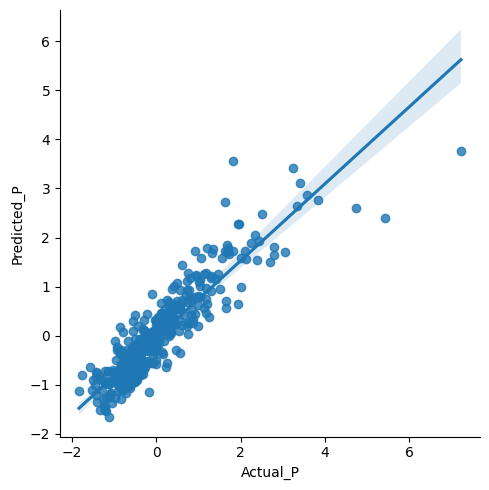

In [61]:
# plotting  Actual vs Predicted
import seaborn as sns
# sns.set()
_=sns.lmplot(x= "Actual_P",  y = "Predicted_P", data=df_pred)

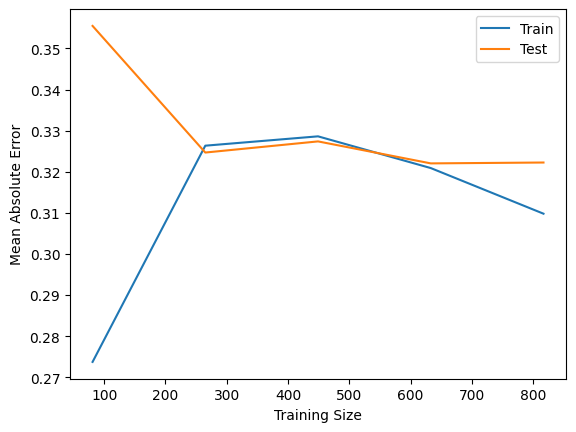

In [67]:
# plot the learning curve
residuals = y_test - y_pred
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(lreg, X_train, y_train, scoring="neg_mean_absolute_error")
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, -test_scores.mean(axis=1), label="Test")
plt.xlabel("Training Size")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

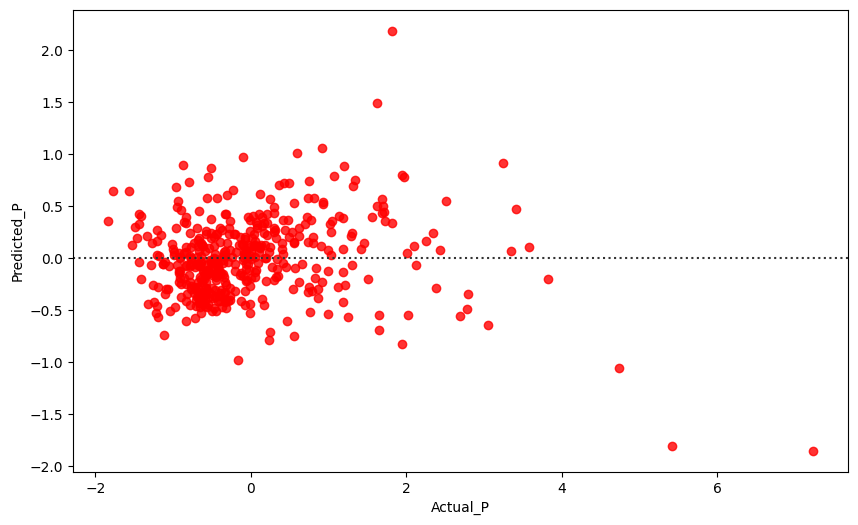

In [66]:
# residual plot
plt.figure(figsize=(10,6))
_=sns.residplot(x=df_pred.Actual_P,y= df_pred.Predicted_P, color="r")

In [ ]:
# يمكن مناقشة أي الدرجات تلائم منحى البيانات بغرض التحصل على تنبؤ مرضي